# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



# What the raw tables tell us
- `alldata.xlsx` columns tell us about as follows:
    - numbered columns (530-563) refer to the ID of the question of the `drq.xlsx`
    - number with alphabet: id of the questions which can be found on the `tv2q.xlsx`
    - candidate infos
      *  name
      *  party
      *  age (at 2022)
      *  responsible on which region
  

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task01: check outliers (age)

In [109]:
raw_all_data = pd.read_excel("alldata.xlsx")
raw_all_data.head()


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


In [110]:
raw_all_data.isnull().sum()

530          0
531          0
533          0
534          0
535          0
537          0
538          0
540          0
541          0
543          0
544          0
545          0
546          0
547          0
548          0
550          0
551          0
552          0
553          0
555          0
556          0
557          0
559          0
561          0
563          0
navn         0
parti        0
1a           0
1b           0
2a           0
2b           0
3a           0
3b           0
4a           0
4b           0
5a           0
5b           0
6a           0
6b           0
7a           0
7b           0
8a           0
8b           0
9a           0
9b           0
10a          0
10b          0
11a          0
11b          0
12a          0
12b          0
storkreds    0
alder        0
dtype: int64

In [111]:
missing_percent = raw_all_data.isnull().mean() * 100
print(missing_percent)

530          0.0
531          0.0
533          0.0
534          0.0
535          0.0
537          0.0
538          0.0
540          0.0
541          0.0
543          0.0
544          0.0
545          0.0
546          0.0
547          0.0
548          0.0
550          0.0
551          0.0
552          0.0
553          0.0
555          0.0
556          0.0
557          0.0
559          0.0
561          0.0
563          0.0
navn         0.0
parti        0.0
1a           0.0
1b           0.0
2a           0.0
2b           0.0
3a           0.0
3b           0.0
4a           0.0
4b           0.0
5a           0.0
5b           0.0
6a           0.0
6b           0.0
7a           0.0
7b           0.0
8a           0.0
8b           0.0
9a           0.0
9b           0.0
10a          0.0
10b          0.0
11a          0.0
11b          0.0
12a          0.0
12b          0.0
storkreds    0.0
alder        0.0
dtype: float64


Text(0.5, 1.0, 'Age')

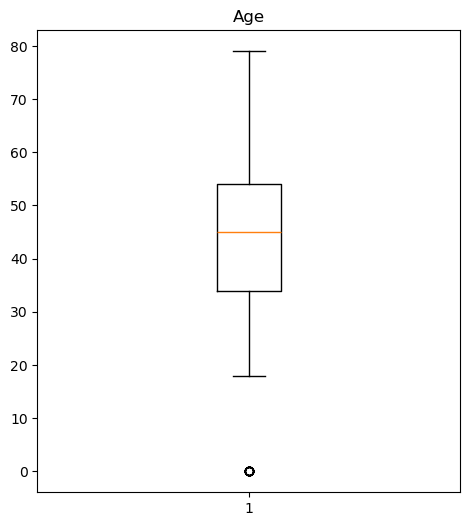

In [112]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(raw_all_data['alder'].dropna())
plt.title('Age')

let's get rid of outlier (age $=0$ doesn't make sense)

Text(0.5, 1.0, 'Age')

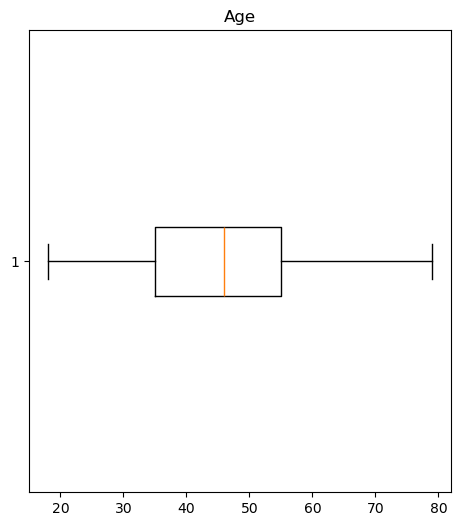

In [113]:
Q1 = raw_all_data['alder'].quantile(0.25)
Q3 = raw_all_data['alder'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR # no need upper bound cuz outliers are only on the lower end
raw_all_data_filtered = raw_all_data[(raw_all_data['alder'] >= lower_bound)]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(raw_all_data_filtered['alder'].dropna(), vert=False)
plt.title('Age')

It's a bit left skewed, not that much, no apply function needed, but we can applying the plot with increase derivative function like $x^2$ if needed for bell curve function

In [114]:
average_age_by_party = raw_all_data_filtered.groupby('parti')['alder'].mean()

# If you want to sort the results to make it easier to read:
average_age_by_party = average_age_by_party.sort_values()

print(average_age_by_party)

parti
Frie Grønne, Danmarks Nye Venstrefløjsparti    34.807692
Liberal Alliance                               37.970588
Socialistisk Folkeparti                        41.521739
Enhedslisten                                   42.225352
Moderaterne                                    44.261905
Det Konservative Folkeparti                    44.723404
Radikale Venstre                               44.955224
Socialdemokratiet                              45.388235
Dansk Folkeparti                               45.530612
Venstre                                        46.678571
Alternativet                                   47.415385
Løsgænger                                      48.000000
Nye Borgerlige                                 48.520000
Kristendemokraterne                            50.219512
Danmarksdemokraterne                           51.216216
Name: alder, dtype: float64


Task02: find the most confident candidate
- value of -2 and +2 in numbered and alphabetnumbered column

In [115]:
# 1. Identify which columns contain the answers (question columns)
# Here we just drop the metadata columns like 'navn', 'parti', 'alder', etc.
metadata_cols = ['navn', 'parti', 'alder', 'storkreds']
question_cols = [col for col 
                 in raw_all_data_filtered.columns 
                 if col not in metadata_cols]

# 2. Check if the value is either -2 or 2 in all those columns
# .isin() returns a boolean True/False dataframe
is_confident = raw_all_data_filtered[question_cols].isin([-2, 2])

raw_all_data_filtered['confident_answers_sum'] = is_confident.sum(axis=1)

# 3. View the result sorted by the most confident candidates (both strongly agreeing and strongly disagreeing)
most_confident = raw_all_data_filtered[['navn', 'parti', 'confident_answers_sum']].sort_values(by='confident_answers_sum', ascending=False)
most_confident.head(10)

C:\Users\konkd\AppData\Local\Temp\ipykernel_32708\1493754156.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_all_data_filtered['confident_answers_sum'] = is_confident.sum(axis=1)


,navn,parti,confident_answers_sum
88,Søren Vanting,Det Konservative Folkeparti,49
505,Sarah Nørris,Enhedslisten,49
559,Kim Andkjær Doberck,Nye Borgerlige,44
152,Rashid Ali,"Frie Grønne, Danmarks Nye Venstrefløjsparti",43
44,Mohamed Abdikarim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",43
151,Elise Bjerkrheim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",42
284,John Bjerg,Nye Borgerlige,42
359,Frank Sørensen,Dansk Folkeparti,42
503,Jan Filbært,Enhedslisten,42
437,Lone Vase Langballe,Dansk Folkeparti,42


Task03: measures the disagreement
- can be done by checking the variance
  - if it's low then it's "agreeing"
  - else "disagree"

In [116]:
# Group by party and calculate variance for all question columns
party_variance = raw_all_data_filtered.groupby('parti')[question_cols].var()

# Sum the variances across all questions to get a total disagreement score
total_disagreement = party_variance.sum(axis=1).sort_values(ascending=False)

print("Parties ranked by internal disagreement (highest to lowest):")
print(total_disagreement)

Parties ranked by internal disagreement (highest to lowest):
parti
Løsgænger                                      129.000000
Kristendemokraterne                             54.154878
Alternativet                                    44.525481
Det Konservative Folkeparti                     42.856326
Dansk Folkeparti                                42.531463
Moderaterne                                     41.904762
Radikale Venstre                                39.376300
Venstre                                         36.756598
Socialdemokratiet                               35.581232
Frie Grønne, Danmarks Nye Venstrefløjsparti     31.863077
Liberal Alliance                                31.704785
Enhedslisten                                    27.890946
Socialistisk Folkeparti                         24.130861
Danmarksdemokraterne                            20.447447
Nye Borgerlige                                  19.948980
dtype: float64


In [119]:
# Calculate the average answer for each party per question
variance_means = raw_all_data_filtered.groupby('parti')[question_cols].mean().var().sort_values(ascending=False)

print("Most polarizing questions between parties:")
print(variance_means.head())

Most polarizing questions between parties:
555    2.339205
3b     2.278430
6a     2.177149
531    2.138076
6b     2.136073
dtype: float64
